No se encontró CSV fuente; usando esquema por defecto para generar datos sintéticos.

Dataset sintético generado -> shape: (1000, 29)
Columnas numéricas: 24
Ejemplo (primeras 5 filas):


,study_hours_wk,sleep_hours,lms_activity_rate,attendance_rate,assignments_on_time_rate,procrastination_index,self_efficacy,stress,internet_quality,part_time_job_hours,...,lms_forum_rate,lms_resource_rate,lms_submission_rate,attendance_lecture,attendance_lab,cluster_label_true,major,primary_device,internet_type,cohort
0,15.648610,7.943657,74.150028,72.542277,87.366260,47.030312,51.873889,38.782465,81.410935,3.821409,...,30.575194,59.031056,75.341777,83.160042,87.911039,A,Administración,Laptop,Fibra,2024
1,13.006382,7.403938,63.206860,69.970999,89.781450,48.267404,55.639852,41.082122,81.966118,3.466585,...,37.443552,52.743923,80.558143,89.483697,92.406045,A,Industrial,Smartphone,Fibra,2022
2,15.271103,7.848896,69.707319,74.733623,94.046426,48.441977,48.937049,37.970352,86.456669,3.029043,...,30.540117,58.620176,80.972556,82.049153,90.440022,A,Industrial,Smartphone,DSL,2025
3,12.299690,7.516912,71.896759,72.683150,98.634935,47.564424,53.122897,39.589544,86.158489,1.524165,...,37.782612,54.998315,84.478482,85.514142,94.176771,A,Psicología,Laptop,Móvil,2024
4,14.283508,7.487901,64.031483,74.637479,89.360774,49.855644,50.660653,41.249569,83.501256,3.359793,...,34.306889,57.992519,79.919084,83.094560,89.415702,A,Industrial,Desktop,Fibra,2022


CSV guardado en: synthetic_edu_insight360.csv
PCA variance ratio (first 4): [0.476  0.3805 0.0417 0.0316]
K=4 -> silhouette: 0.574, Davies-Bouldin: 0.652, Calinski-Harabasz: 1627.2


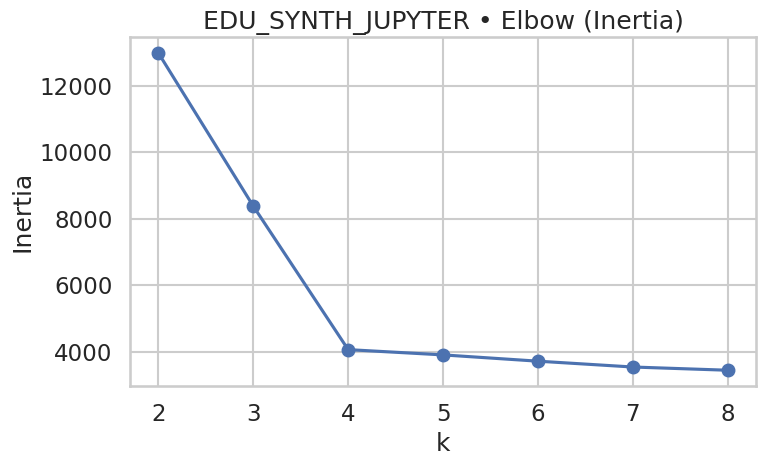

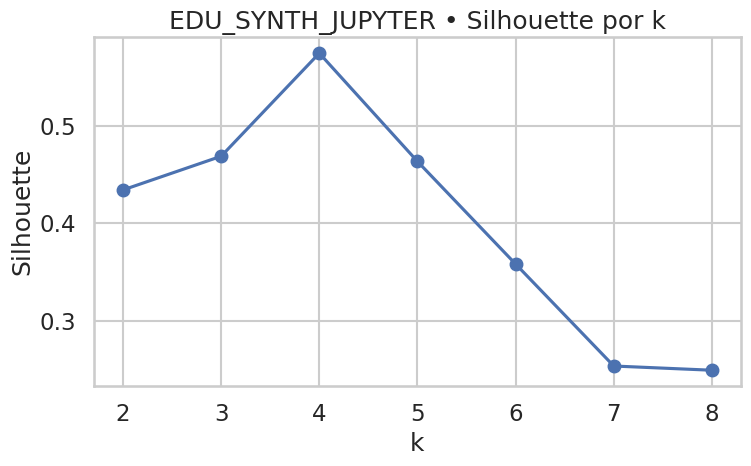

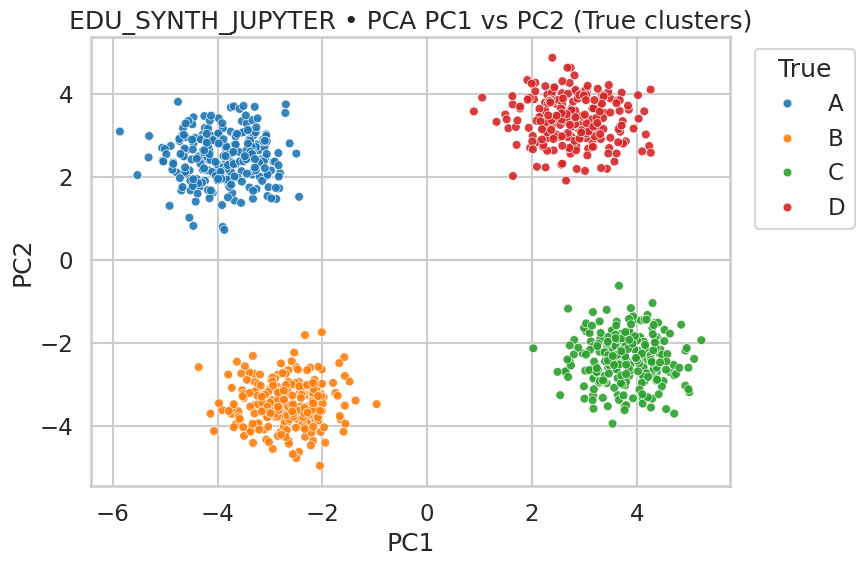

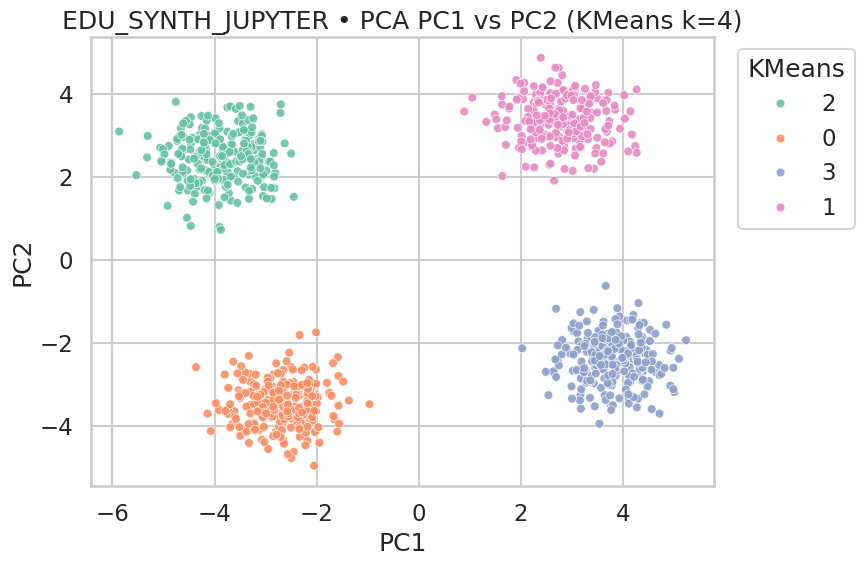

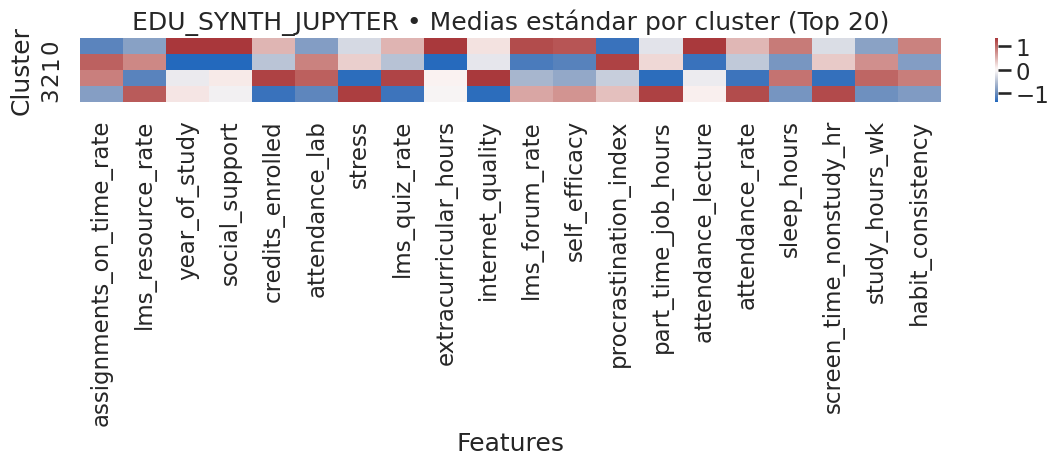


Métricas principales:
 - pca_var_first4: [0.476  0.3805 0.0417 0.0316]
 - silhouette_k4: 0.5742418838964931
 - db_k4: 0.6523481998154205
 - ch_k4: 1627.1724220732826
 - labels_k4: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 

In [3]:
# CELDA: Generar dataset sintético con 4 clusters (1000 registros) + PCA + KMeans (Jupyter-ready)
# =================================================================================================
# Requisitos: pandas, numpy, scikit-learn, seaborn, matplotlib
# Ejecuta: pip install -U pandas numpy scikit-learn seaborn matplotlib   (si falta algo)
# =================================================================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Parámetros ----------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

N = 1000               # <-- número de registros pedidos
K = 4                  # número de clusters deseados
PCA_RADIUS = 3.0       # separación entre centroides en espacio PCA (ajustable)
PCA_SPREAD = 0.35      # dispersión alrededor de centroides en espacio PCA (ajustable)
FIGS_DIR = "figs"
OUT_CSV = "synthetic_edu_insight360.csv"
TITLE_PREFIX = "EDU_SYNTH_JUPYTER"

os.makedirs(FIGS_DIR, exist_ok=True)
sns.set(style="whitegrid", context="talk")

# ---------- Utilidades ----------
def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def clip_by_quantiles(Xdf, q_low=0.005, q_high=0.995):
    qlo = Xdf.quantile(q_low)
    qhi = Xdf.quantile(q_high)
    return Xdf.clip(lower=qlo, upper=qhi, axis=1)

def force_logical_ranges(df):
    # reglas heurísticas simples
    for col in df.columns:
        lc = col.lower()
        if "rate" in lc or "pct" in lc or "percentage" in lc or "attendance" in lc:
            df[col] = df[col].clip(lower=0, upper=100)
        if "hours" in lc or "time" in lc or "min" in lc:
            df[col] = df[col].clip(lower=0)
        if "age" == lc:
            df[col] = df[col].clip(lower=16, upper=80)
    return df

# ---------- Si no tienes CSV fuente, se crea un esquema por defecto ----------
def make_default_source(nbase=1200):
    # columnas numéricas plausibles (educativas)
    cols_num = [
        "study_hours_wk","sleep_hours","lms_activity_rate","attendance_rate",
        "assignments_on_time_rate","procrastination_index","self_efficacy",
        "stress","internet_quality","part_time_job_hours","commute_min",
        "social_support","screen_time_nonstudy_hr","extracurricular_hours",
        "habit_consistency","age","credits_enrolled","year_of_study",
        "lms_quiz_rate","lms_forum_rate","lms_resource_rate","lms_submission_rate",
        "attendance_lecture","attendance_lab"
    ]
    base = pd.DataFrame(np.random.normal(size=(nbase,len(cols_num))), columns=cols_num)
    # transformar a rangos razonables
    base["study_hours_wk"] = np.abs(base["study_hours_wk"]*5+12)
    base["sleep_hours"] = np.clip(base["sleep_hours"]*1.2+7.2, 3, 12)
    base["attendance_rate"] = np.clip((base["attendance_rate"]*15+85), 0, 100)
    base["lms_activity_rate"] = np.clip((base["lms_activity_rate"]*20+70), 0, 100)
    base["assignments_on_time_rate"] = np.clip((base["assignments_on_time_rate"]*20+80), 0, 100)
    base["procrastination_index"] = np.clip((base["procrastination_index"]*10+50), 0, 100)
    base["self_efficacy"] = np.clip((base["self_efficacy"]*12+60), 0, 100)
    base["stress"] = np.clip((base["stress"]*12+50), 0, 100)
    base["internet_quality"] = np.clip((base["internet_quality"]*15+70), 0, 100)
    base["part_time_job_hours"] = np.abs(base["part_time_job_hours"]*4+6)
    base["commute_min"] = np.abs(base["commute_min"]*8+25)
    base["social_support"] = np.clip((base["social_support"]*12+60), 0, 100)
    base["screen_time_nonstudy_hr"] = np.abs(base["screen_time_nonstudy_hr"]*2+3)
    base["extracurricular_hours"] = np.abs(base["extracurricular_hours"]*3+4)
    base["habit_consistency"] = np.clip((base["habit_consistency"]*12+60), 0, 100)
    base["age"] = np.clip((base["age"]*3+20), 16, 60)
    base["credits_enrolled"] = np.clip((base["credits_enrolled"]*4+18), 8, 28)
    base["year_of_study"] = np.clip((base["year_of_study"]*1+3), 1, 6)
    base["lms_quiz_rate"] = np.clip((base["lms_quiz_rate"]*18+65), 0, 100)
    base["lms_forum_rate"] = np.clip((base["lms_forum_rate"]*18+40), 0, 100)
    base["lms_resource_rate"] = np.clip((base["lms_resource_rate"]*18+75), 0, 100)
    base["lms_submission_rate"] = np.clip((base["lms_submission_rate"]*18+85), 0, 100)
    base["attendance_lecture"] = np.clip((base["attendance_lecture"]*12+86), 0, 100)
    base["attendance_lab"] = np.clip((base["attendance_lab"]*12+82), 0, 100)

    df_cat = pd.DataFrame({
        "major": np.random.choice(["Sistemas","Industrial","Administración","Psicología"], size=base.shape[0]),
        "primary_device": np.random.choice(["Laptop","Desktop","Tablet","Smartphone"], size=base.shape[0], p=[0.55,0.15,0.10,0.20]),
        "internet_type": np.random.choice(["Fibra","Cable","Móvil","DSL"], size=base.shape[0], p=[0.45,0.25,0.20,0.10]),
        "cohort": np.random.choice(["2022","2023","2024","2025"], size=base.shape[0])
    })
    return pd.concat([base, df_cat], axis=1)

# ---------- Generador sintético guiado por PCA ----------
def generate_synthetic(source_df=None, n_rows=1000, k=4, radius=3.0, spread=0.35):
    if source_df is None:
        source_df = make_default_source()
    # columnas numéricas y categóricas
    num_cols = source_df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = source_df.select_dtypes(exclude=[np.number]).columns.tolist()

    # escalar y PCA
    X = source_df[num_cols].copy()
    scaler = StandardScaler()
    Xz = scaler.fit_transform(X)

    pca = PCA(n_components=min(8, Xz.shape[1]), random_state=RANDOM_STATE)
    Z = pca.fit_transform(Xz)

    # centroides en círculo en las dos primeras componentes
    angles = np.linspace(0, 2*np.pi, k, endpoint=False)
    centroids = np.stack([radius*np.cos(angles), radius*np.sin(angles)], axis=1)
    C = np.zeros((k, Z.shape[1]))
    C[:, :2] = centroids

    # tamaños por cluster
    base = n_rows // k
    sizes = [base + (1 if i < (n_rows % k) else 0) for i in range(k)]

    Z_synth = []
    labels = []
    for i, s in enumerate(sizes):
        noise = np.random.normal(loc=0.0, scale=spread, size=(s, Z.shape[1]))
        Zi = C[i] + noise
        Z_synth.append(Zi)
        labels.extend([i]*s)

    Z_synth = np.vstack(Z_synth)
    labels = np.array(labels)

    # volver al espacio original
    Xz_synth = pca.inverse_transform(Z_synth)
    X_synth = scaler.inverse_transform(Xz_synth)
    df_num = pd.DataFrame(X_synth, columns=num_cols)
    df_num = clip_by_quantiles(df_num, 0.005, 0.995)
    df_num = force_logical_ranges(df_num)

    # categorías: muestreo sesgado por cluster
    df = df_num.copy()
    label_map = {i: chr(65+i) for i in range(k)}   # {0:'A',1:'B',...}
    df["cluster_label_true"] = [label_map[i] for i in labels]

    for col in cat_cols:
        vals = source_df[col].astype(str).value_counts(normalize=True)
        cats = vals.index.tolist()
        probs = vals.values.tolist()
        # crear variaciones por cluster
        choices = []
        for i, s in enumerate(sizes):
            rotated = np.roll(probs, i)
            mix = 0.7*np.array(probs) + 0.3*np.array(rotated)
            mix /= mix.sum()
            choices.extend(np.random.choice(cats, size=s, p=mix))
        df[col] = choices

    # ordenar columnas (numéricas primero)
    ordered = num_cols + ["cluster_label_true"] + [c for c in cat_cols if c not in ["cluster_label_true"]]
    # asegurar existencia única
    df = df.loc[:, [c for c in ordered if c in df.columns]]

    return df, num_cols

# ---------- Clustering, PCA y gráficos inline ----------
def analyze_and_plot(df, num_cols, figs_dir=FIGS_DIR, prefix=TITLE_PREFIX):
    ensure_dir(figs_dir)
    X = df[num_cols].values
    scaler = StandardScaler()
    Xz = scaler.fit_transform(X)

    # PCA
    pca = PCA(n_components=min(6, Xz.shape[1]), random_state=RANDOM_STATE)
    Z = pca.fit_transform(Xz)
    print(f"PCA variance ratio (first 4): {np.round(pca.explained_variance_ratio_[:4],4)}")

    # pruebas k
    ks = list(range(2,9))
    inertias = []
    sils = []
    for k in ks:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
        lab = km.fit_predict(Xz)
        inertias.append(km.inertia_)
        sils.append(silhouette_score(Xz, lab))

    # K=4 metrics & labels
    km4 = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init="auto")
    lab4 = km4.fit_predict(Xz)
    sil4 = silhouette_score(Xz, lab4)
    db4 = davies_bouldin_score(Xz, lab4)
    ch4 = calinski_harabasz_score(Xz, lab4)

    print(f"K=4 -> silhouette: {sil4:.3f}, Davies-Bouldin: {db4:.3f}, Calinski-Harabasz: {ch4:.1f}")

    # --- Gráficos ---
    plt.figure(figsize=(8,5))
    plt.plot(ks, inertias, marker='o')
    plt.title(f"{prefix} • Elbow (Inertia)")
    plt.xlabel("k")
    plt.ylabel("Inertia")
    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(figs_dir, f"{prefix}_elbow.png"), dpi=180)
    plt.close()

    plt.figure(figsize=(8,5))
    plt.plot(ks, sils, marker='o')
    plt.title(f"{prefix} • Silhouette por k")
    plt.xlabel("k")
    plt.ylabel("Silhouette")
    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(figs_dir, f"{prefix}_silhouette_k.png"), dpi=180)
    plt.close()

    # PCA scatter por true cluster
    plt.figure(figsize=(9,6))
    sns.scatterplot(x=Z[:,0], y=Z[:,1], hue=df["cluster_label_true"].astype(str), s=40, alpha=0.9, palette="tab10")
    plt.title(f"{prefix} • PCA PC1 vs PC2 (True clusters)")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.legend(title="True", bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(figs_dir, f"{prefix}_pca_true.png"), dpi=180, bbox_inches="tight")
    plt.close()

    # PCA scatter por kmeans(4)
    plt.figure(figsize=(9,6))
    sns.scatterplot(x=Z[:,0], y=Z[:,1], hue=lab4.astype(str), s=40, alpha=0.9, palette="Set2")
    plt.title(f"{prefix} • PCA PC1 vs PC2 (KMeans k=4)")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.legend(title="KMeans", bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(figs_dir, f"{prefix}_pca_kmeans4.png"), dpi=180, bbox_inches="tight")
    plt.close()

    # Heatmap de medias z por cluster k4 (top 20 features)
    dfz = pd.DataFrame(Xz, columns=num_cols)
    dfz['k4'] = lab4
    means = dfz.groupby('k4').mean()
    between_var = means.var(axis=0).sort_values(ascending=False)
    top_feats = between_var.index[:20].tolist()

    plt.figure(figsize=(12,5))
    sns.heatmap(means[top_feats], cmap="vlag", center=0, annot=False)
    plt.title(f"{prefix} • Medias estándar por cluster (Top 20)")
    plt.xlabel("Features"); plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(figs_dir, f"{prefix}_heatmap_top20.png"), dpi=180)
    plt.close()

    # Retornar métricas y labels
    return {"pca_var_first4": pca.explained_variance_ratio_[:4], "silhouette_k4": sil4, "db_k4": db4, "ch_k4": ch4, "labels_k4": lab4}

# ---------------- Ejecutar todo en Jupyter ----------------
# Si tienes un CSV propio, pon la ruta aquí:
SOURCE_CSV = None   # ej: "edu_insight360_PERFECT_clusters (1).csv"

if SOURCE_CSV is not None and os.path.isfile(SOURCE_CSV):
    print(f"Cargando CSV fuente: {SOURCE_CSV}")
    src_df = pd.read_csv(SOURCE_CSV)
else:
    src_df = None
    print("No se encontró CSV fuente; usando esquema por defecto para generar datos sintéticos.")

synthetic_df, numeric_columns = generate_synthetic(source_df=src_df, n_rows=N, k=K, radius=PCA_RADIUS, spread=PCA_SPREAD)

print(f"\nDataset sintético generado -> shape: {synthetic_df.shape}")
print("Columnas numéricas:", len(numeric_columns))
print("Ejemplo (primeras 5 filas):")
display(synthetic_df.head())

# Guardar CSV
synthetic_df.to_csv(OUT_CSV, index=False, encoding="utf-8")
print(f"CSV guardado en: {OUT_CSV}")

# Análisis y visualización inline
metrics = analyze_and_plot(synthetic_df, numeric_columns, figs_dir=FIGS_DIR, prefix=TITLE_PREFIX)

print("\nMétricas principales:")
for k, v in metrics.items():
    if hasattr(v, "__len__") and not isinstance(v, str):
        print(f" - {k}: {np.round(np.array(v, dtype=float), 4)}")
    else:
        print(f" - {k}: {v}")

print(f"\nFiguras también guardadas en la carpeta '{FIGS_DIR}'.")
